# Option C: BETER Internal Microstructure

## Research question

How quickly and how far does BETER reprice its match-winner market after a new match incident, and are its margin-free probabilities calibrated to realized settlements?

This notebook studies the bookmaker feed internally. It joins the venue-side `incident` stream to the `trading` stream, using the `time_table` capture for match identity, sport, and participants. The central market-microstructure object is the response from an observed event to the next meaningful probability update.

## Hypotheses

1. BETER reprices shortly after an incident, but the response latency varies by sport and event type.
2. Table-tennis events, keyed by a human scout, have slower and more dispersed incident-to-trading latency than machine-fed eFootball events.
3. Repricing magnitude depends on the information content of the score state: a routine point should move probability less than a set-winning or match-ending event.
4. BETER's margin-free `probability` field should be meaningfully calibrated against the final settlement outcome, although calibration may vary across sports and probability buckets.

## Timing rules

- Use `recv_wall_ns` as our cross-channel arrival clock.
- Use `recv_mono_ns` for within-capture duration calculations when available.
- Use `incident.index` to order incidents within a match.
- Deduplicate trading states by `(match_id, offset)` and incidents by `(match_id, index)`.
- Do not use the provider's `timestamp` as an event clock: it describes source state and can move backward across message types.

The final analysis will report latency distributions, probability-jump sizes by incident type and score state, a TT-versus-eFootball comparison with match-level uncertainty, and calibration metrics including Brier score, log loss, and reliability curves.

In [1]:
from pathlib import Path
import json
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# The notebook lives in analysis/, so these paths resolve from that folder.
NOTEBOOK_DIR = Path.cwd()
DATA_ROOT = NOTEBOOK_DIR.parent / 'data'
PARSED_ROOT = NOTEBOOK_DIR.parent / 'parsed'
MANIFEST_PATH = DATA_ROOT / 'tt_session' / 'manifest-from-timetable.json'

print(f'Notebook directory: {NOTEBOOK_DIR}')
print(f'Data root:          {DATA_ROOT}')
print(f'Parsed data root:   {PARSED_ROOT}')
print(f'Manifest exists:    {MANIFEST_PATH.exists()}')

assert DATA_ROOT.exists(), f'Missing data directory: {DATA_ROOT}'
assert PARSED_ROOT.exists(), f'Missing parsed directory: {PARSED_ROOT}'
assert MANIFEST_PATH.exists(), f'Missing manifest: {MANIFEST_PATH}'

Matplotlib is building the font cache; this may take a moment.


Notebook directory: c:\Users\ishan\Downloads\tauroi_technologies_homework\homework\tt-homework\analysis
Data root:          c:\Users\ishan\Downloads\tauroi_technologies_homework\homework\tt-homework\data
Parsed data root:   c:\Users\ishan\Downloads\tauroi_technologies_homework\homework\tt-homework\parsed
Manifest exists:    True


## 1. Load and identify the captured markets

The parsed trading table is large, so we load only the columns needed for Option C. The manifest gives us the sport label and match names; the BETER tables provide the event and market state. We preserve the provider's row order only as a file-reading detail and use the recorded receive clocks for all timing calculations.

In [2]:
# Load the manifest and compact event/score tables.
with MANIFEST_PATH.open(encoding='utf-8') as f:
    manifest = json.load(f)

bookings = pd.DataFrame.from_dict(manifest['bookings'], orient='index')
bookings.index.name = 'match_id'
bookings = bookings.reset_index()
bookings['sport'] = bookings['sport'].fillna('Unknown')

incident_cols = [
    'recv_wall_ns', 'recv_mono_ns', 'match_id', 'index',
    'incident_type', 'occurred_date', 'params_json'
]
incidents = pd.read_csv(PARSED_ROOT / 'incidents.csv', usecols=incident_cols)
incidents = incidents.merge(bookings[['match_id', 'sport', 'name']], on='match_id', how='left')
incidents['recv_wall_s'] = incidents['recv_wall_ns'] / 1e9
incidents['recv_mono_s'] = incidents['recv_mono_ns'] / 1e9
incidents['index'] = pd.to_numeric(incidents['index'], errors='coerce')

scoreboard_cols = [
    'recv_wall_ns', 'recv_mono_ns', 'match_id', 'offset',
    'stage', 'server', 'scores_json', 'timer_json'
]
scoreboard = pd.read_csv(PARSED_ROOT / 'scoreboard.csv', usecols=scoreboard_cols)
scoreboard = scoreboard.merge(bookings[['match_id', 'sport']], on='match_id', how='left')
scoreboard['recv_wall_s'] = scoreboard['recv_wall_ns'] / 1e9
scoreboard['recv_mono_s'] = scoreboard['recv_mono_ns'] / 1e9

# Read only the match-winner probability rows from trading.csv in chunks.
trading_cols = [
    'recv_wall_ns', 'recv_mono_ns', 'match_id', 'offset',
    'msg_type', 'trading_status', 'market_id', 'market_type',
    'market_value', 'outcome_id', 'outcome_type', 'outcome_value',
    'price', 'probability', 'outcome_status', 'outcome_result'
]
trading_parts = []
for chunk in pd.read_csv(PARSED_ROOT / 'trading.csv', usecols=trading_cols,
                         chunksize=500_000, low_memory=False):
    # Option C needs active match-winner states and eventual settlement rows.
    chunk['probability'] = pd.to_numeric(chunk['probability'], errors='coerce')
    chunk['outcome_result'] = pd.to_numeric(chunk['outcome_result'], errors='coerce')
    keep = chunk['probability'].notna() | chunk['outcome_result'].notna()
    if keep.any():
        trading_parts.append(chunk.loc[keep].copy())

trading = pd.concat(trading_parts, ignore_index=True)
trading = trading.merge(bookings[['match_id', 'sport', 'name']], on='match_id', how='left')
trading['recv_wall_s'] = trading['recv_wall_ns'] / 1e9
trading['recv_mono_s'] = trading['recv_mono_ns'] / 1e9
trading['probability'] = trading['probability'].clip(0, 1)

print(f"Matches in manifest: {len(bookings):,}")
print(f"Incidents:           {len(incidents):,}")
print(f"Scoreboard states:   {len(scoreboard):,}")
print(f"Trading probability/settlement rows: {len(trading):,}")
print('\nMatches by sport:')
display(bookings['sport'].value_counts().to_frame('matches').head(10))

Matches in manifest: 2,818
Incidents:           135,723
Scoreboard states:   59,650
Trading probability/settlement rows: 11,794,735

Matches by sport:


,matches
sport,
Fifa,2060
TableTennis,755
CounterStrike,3


## 2. Data-quality checks and market selection

Before measuring reactions, we check duplicates, sequence gaps, missing sport labels, and the available BETER market taxonomy. The selected market must be a binary match-winner market with probabilities for both outcomes and a final settlement result.

In [3]:
# Basic integrity checks.
quality = {
    'duplicate_incident_keys': int(incidents.duplicated(['match_id', 'index']).sum()),
    'duplicate_trading_keys': int(trading.duplicated(['match_id', 'offset']).sum()),
    'incidents_missing_sport': int(incidents['sport'].isna().sum()),
    'trading_missing_sport': int(trading['sport'].isna().sum()),
    'incident_matches': int(incidents['match_id'].nunique()),
    'trading_matches': int(trading['match_id'].nunique()),
}
print('Integrity checks:')
display(pd.Series(quality, name='count').to_frame())

# Sequence gaps are measured only between observed incident indices within a match.
incident_sequences = (
    incidents.dropna(subset=['index'])
    .sort_values(['match_id', 'index'])
    .groupby('match_id')['index']
    .agg(lambda s: int((s.diff().dropna() > 1).sum()))
)
print(f"Matches with incident-index gaps: {(incident_sequences > 0).sum():,}")
print(f"Total positive incident-index gaps: {incident_sequences.sum():,}")

print('Market taxonomy:')
display(trading.groupby(['market_type', 'market_value'], dropna=False)
        .size().sort_values(ascending=False).head(20).to_frame('rows'))
print('Outcome taxonomy:')
display(trading.groupby(['outcome_type', 'outcome_value'], dropna=False)
        .size().sort_values(ascending=False).head(20).to_frame('rows'))

print('Incident types by sport:')
display(pd.crosstab(incidents['sport'], incidents['incident_type']).iloc[:, :20])

Integrity checks:


,count
duplicate_incident_keys,0
duplicate_trading_keys,11700973
incidents_missing_sport,0
trading_missing_sport,0
incident_matches,1173
trading_matches,1422


Matches with incident-index gaps: 1,172
Total positive incident-index gaps: 80,637
Market taxonomy:


,,rows
market_type,market_value,
4,NaN,2380351
15,NaN,513252
8,NaN,336576
1,NaN,327028
12,NaN,322866
37,NaN,249342
3,0,176706
14,1,171153
25,NaN,161695


Outcome taxonomy:


,,rows
outcome_type,outcome_value,
4,NaN,2110566
5,NaN,2110566
1,NaN,1579325
3,NaN,1579325
14,NaN,224451
2,NaN,112197
9,NaN,107627
10,NaN,107627
11,NaN,107627


Incident types by sport:


incident_type,2,3,5,7,17,18,1001,1002,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016
sport,,,,,,,,,,,,,,,,,,,,
CounterStrike,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Fifa,0,0,4,4,15,24,0,0,0,0,0,0,0,0,0,0,0,0,3,0
TableTennis,138,3,23,35,0,0,35,4,175,174,447,438,1786,1777,33317,33357,1,1,12,12


## 3. Define the match-winner probability series

The parser emits one row per outcome, so a legitimate trading state appears twice for a binary market. We therefore identify the winner market using the market taxonomy and retain the two outcome rows needed to reconstruct a single focal probability per match.

In [4]:
# Correct the row-level duplicate diagnostic: outcomes are part of the state key.
state_key = ['match_id', 'offset', 'market_id', 'outcome_id']
print('Duplicate parsed state rows:', int(trading.duplicated(state_key).sum()))

# Market type 1 is the match-winner market in the captured BETER schema.
winner_rows = trading[trading['market_type'].eq(1)].copy()
print(f'Winner-market rows: {len(winner_rows):,}')
print('Winner market rows by sport:')
display(winner_rows.groupby('sport').size().to_frame('rows'))

winner_outcomes = (winner_rows.groupby(['sport', 'outcome_type'], dropna=False)
                   .size().sort_values(ascending=False).to_frame('rows'))
print('Winner outcome types:')
display(winner_outcomes.head(20))

# Select the focal outcome as the first winner-market outcome observed per match.
# The complement is useful as a consistency check, but all response analysis uses
# one stable focal outcome per match to avoid double-counting a single repricing.
first_outcome = (winner_rows.sort_values(['match_id', 'recv_wall_ns', 'outcome_id'])
                 .drop_duplicates(['match_id'])
                 [['match_id', 'outcome_id', 'outcome_type', 'outcome_value']]
                 .rename(columns={'outcome_id': 'focal_outcome_id',
                                  'outcome_type': 'focal_outcome_type',
                                  'outcome_value': 'focal_outcome_value'}))

winner_focal = winner_rows.merge(first_outcome, on='match_id', how='inner')
# Keep probability-bearing rows for the focal outcome and settlement rows for it.
winner_focal = winner_focal[winner_focal['outcome_id'].eq(winner_focal['focal_outcome_id'])].copy()
winner_focal = winner_focal.sort_values(['match_id', 'recv_wall_ns', 'offset'])

print(f'Focal winner rows: {len(winner_focal):,}')
print(f'Focal matches:     {winner_focal.match_id.nunique():,}')
display(winner_focal[['match_id', 'sport', 'outcome_type', 'probability',
                      'trading_status', 'outcome_status', 'outcome_result']].head())

Duplicate parsed state rows: 0
Winner-market rows: 327,028
Winner market rows by sport:


,rows
sport,
CounterStrike,58
TableTennis,326970


Winner outcome types:


rows
sport         outcome_type        
TableTennis   3             163485
              1             163485
CounterStrike 3                 29
              1                 29

Focal winner rows: 163,514
Focal matches:     545


,match_id,sport,outcome_type,probability,trading_status,outcome_status,outcome_result
768,00460e9f-6062-4d10-87eb-32c345e32b10,TableTennis,1,0.001779,3,3,3
770,00460e9f-6062-4d10-87eb-32c345e32b10,TableTennis,1,0.221181,3,3,3
772,00460e9f-6062-4d10-87eb-32c345e32b10,TableTennis,1,0.250388,3,3,3
774,00460e9f-6062-4d10-87eb-32c345e32b10,TableTennis,1,0.010260,3,3,3
776,00460e9f-6062-4d10-87eb-32c345e32b10,TableTennis,1,0.416422,3,3,4


In [5]:
# Inspect one complete winner-market match to verify outcome identity and settlement encoding.
example_match = winner_rows.loc[winner_rows['sport'].eq('TableTennis'), 'match_id'].iloc[0]
example = (winner_rows[winner_rows['match_id'].eq(example_match)]
           .sort_values(['recv_wall_ns', 'offset', 'outcome_id']))
print('Example match:', example_match)
print('Columns describing the state:')
display(example[['recv_wall_ns', 'offset', 'trading_status', 'outcome_id',
                 'outcome_type', 'probability', 'outcome_status',
                 'outcome_result']].tail(20))
print('Outcome result values:', sorted(example['outcome_result'].dropna().unique().tolist()))
print('Trading status values:', sorted(example['trading_status'].dropna().unique().tolist()))
print('Probabilities per outcome:')
display(example.groupby('outcome_type')['probability'].agg(['count', 'min', 'max']))

Example match: 99638cdd-59b2-4524-b946-5ac70aa02dee
Columns describing the state:


,recv_wall_ns,offset,trading_status,outcome_id,outcome_type,probability,outcome_status,outcome_result
85739,1787918865040202435,1704686523567,3,"[1,[]]",1,0.999686,3,2
85741,1787918865040202435,1704686523567,3,"[1,[]]",1,0.807439,3,2
85743,1787918865040202435,1704686523567,3,"[1,[]]",1,0.771972,3,2
85745,1787918865040202435,1704686523567,3,"[1,[]]",1,0.997112,3,2
85747,1787918865040202435,1704686523567,3,"[1,[]]",1,0.670476,3,4
85740,1787918865040202435,1704686523567,3,"[3,[]]",3,0.000314,3,3
85742,1787918865040202435,1704686523567,3,"[3,[]]",3,0.192561,3,3
85744,1787918865040202435,1704686523567,3,"[3,[]]",3,0.228028,3,3
85746,1787918865040202435,1704686523567,3,"[3,[]]",3,0.002888,3,3
85748,1787918865040202435,1704686523567,3,"[3,[]]",3,0.329524,3,4


Outcome result values: [0, 2, 3, 4]
Trading status values: [1, 3]
Probabilities per outcome:


,count,min,max
outcome_type,,,
1,300,0.267002,0.999686
3,300,0.000314,0.732998


In [6]:
print('Market IDs and outcome values in the example:')
display(example[['market_id', 'market_type', 'market_value', 'outcome_id',
                 'outcome_value', 'price', 'probability']].drop_duplicates()
        .sort_values(['market_id', 'outcome_id']).head(30))
print('Market IDs per match:')
display(example.groupby(['market_id', 'market_type', 'market_value'])
        .size().sort_values(ascending=False).to_frame('rows').head(20))

Market IDs and outcome values in the example:


,market_id,market_type,market_value,outcome_id,outcome_value,price,probability
2,"[1,5,3,0,[]]",1,NaN,"[1,[]]",NaN,1.57,0.597428
33409,"[1,5,3,0,[]]",1,NaN,"[1,[]]",NaN,1.80,0.515428
33427,"[1,5,3,0,[]]",1,NaN,"[1,[]]",NaN,2.15,0.428458
33443,"[1,5,3,0,[]]",1,NaN,"[1,[]]",NaN,1.82,0.506783
33471,"[1,5,3,0,[]]",1,NaN,"[1,[]]",NaN,1.60,0.589005
33477,"[1,5,3,0,[]]",1,NaN,"[1,[]]",NaN,1.38,0.688831
33515,"[1,5,3,0,[]]",1,NaN,"[1,[]]",NaN,1.55,0.603345
33563,"[1,5,3,0,[]]",1,NaN,"[1,[]]",NaN,1.36,0.691213
33581,"[1,5,3,0,[]]",1,NaN,"[1,[]]",NaN,1.23,0.774914
33597,"[1,5,3,0,[]]",1,NaN,"[1,[]]",NaN,1.11,0.861864


Market IDs per match:


,,,rows
market_id,market_type,market_value,


In [7]:
settled_winners = winner_rows[winner_rows['trading_status'].eq(3)].copy()
print('Settlement result by outcome type:')
display(pd.crosstab(settled_winners['outcome_type'], settled_winners['outcome_result'], dropna=False))
print('Rows per timestamp in the winner market:')
rows_per_tick = (winner_rows.groupby(['match_id', 'recv_wall_ns'])
                 .size().describe())
display(rows_per_tick.to_frame('value'))

Settlement result by outcome type:


outcome_result,0,1,2,3,4
outcome_type,,,,,
1,996,13,2025,2039,395
3,996,13,2039,2025,395


Rows per timestamp in the winner market:


,value
count,36711.000000
mean,8.908175
std,2.431886
min,2.000000
25%,6.000000
50%,10.000000
75%,12.000000
max,12.000000


In [8]:
# Identify binary winner-like markets separately by sport.
market_summary = (trading[trading['probability'].notna()]
                  .groupby(['sport', 'market_type', 'market_value'])
                  .agg(rows=('probability', 'size'),
                       matches=('match_id', 'nunique'),
                       outcomes=('outcome_type', 'nunique'))
                  .query('outcomes == 2')
                  .sort_values(['sport', 'matches', 'rows'], ascending=[True, False, False]))
print('Binary market candidates by sport:')
display(market_summary.head(30))

Binary market candidates by sport:


rows  matches  outcomes
sport         market_type market_value                         
CounterStrike 3           -2.5            24        3         2
              10          10.5            22        3         2
              2           21.5            20        3         2
              10          12.5            20        3         2
              11          10.5            20        3         2
              3           -3.5            18        3         2
                          -4.5            18        3         2
                          2.5             18        3         2
              10          11.5            18        3         2
              3           -5.5            16        3         2
              2           19.5            14        3         2
                          20.5            14        3         2
                          22.5            14        3         2
                          23.5            14        3         2
              11          11.5            14        3         2
                          12.5            14        3         2
                          0.5             12        3         2
              2           0.5             10        3         2
              10          0.5             10        3         2
                          3.5             26        2         2
                          8.5             24        2         2
                          4.5             22        2         2
                          5.5             22        2         2
              11          4.5             22        2         2
              3           6.5             20        2         2
                          7.5             20        2         2
              11          8.5             20        2         2
              3           5.5             18        2         2
              10          6.5             18        2         2
              11          5.5             18        2         2

In [9]:
print('Top binary candidates for TableTennis and Fifa:')
display(market_summary[market_summary.index.get_level_values('sport').isin(['TableTennis', 'Fifa'])]
        .sort_values(['sport', 'matches', 'rows'], ascending=[True, False, False])
        .groupby(level='sport').head(12))

Top binary candidates for TableTennis and Fifa:


rows  matches  outcomes
sport market_type market_value                           
Fifa  2           2.5           154076      771         2
                  3.5           147952      747         2
                  4.5           124858      716         2
      18          2.75          126818      715         2
      3           0             176706      690         2
      2           5.5           112268      682         2
                  1.5           135020      677         2
      17          -0.25         139662      673         2
                  0.25          137166      670         2
      18          2.25          117016      665         2
                  3.75           99558      662         2
      11          2.5            98224      661         2

In [10]:
sport_market_counts = (trading[trading['probability'].notna()]
                       .groupby(['sport', 'market_type'], dropna=False)
                       .agg(rows=('probability', 'size'),
                            matches=('match_id', 'nunique'),
                            outcomes=('outcome_type', 'nunique'))
                       .sort_values(['sport', 'matches', 'rows'], ascending=[True, False, False]))
print('Market types by sport:')
display(sport_market_counts)

Market types by sport:


rows  matches  outcomes
sport         market_type                            
CounterStrike 4                769        3         1
              3                238        3         2
              10               220        3         2
              11               174        3         2
              2                136        3         2
              1                 58        3         2
              24                30        3         1
              6                 20        3         2
              29                20        3         4
              9                 15        3         3
              31                15        3         3
              19                10        3         2
              16               324        2         2
              30                42        2         6
              8                 27        2         3
              12                27        2         3
Fifa          4            2379582      877         1
              18           1375858      877         2
              2             954496      877         2
              14            673353      877         3
              15            513252      877         9
              8             336549      877         3
              6             114056      877         2
              10            406906      724         2
              11            401660      724         2
              17            849028      722         2
              3             718906      722         2
              12            322839      680         3
              37            249342      665         6
              27           1081682      663         2
              13             75822      646         2
              26            589830      510         2
              25            161695      212         1
              38            132561      212         1
              39            128223      212         1
TableTennis   1             326970      542         2

In [11]:
fifa_example_match = trading.loc[trading['sport'].eq('Fifa'), 'match_id'].iloc[0]
fifa_example = trading[trading['match_id'].eq(fifa_example_match)].sort_values('recv_wall_ns')
print('Example Fifa match:', fifa_example_match)
print(bookings.loc[bookings['match_id'].eq(fifa_example_match), ['name', 'sport', 'league']].to_string(index=False))
print('Fifa markets and outcomes:')
display(fifa_example[['market_id', 'market_type', 'market_value', 'outcome_id',
                      'outcome_type', 'probability', 'outcome_status',
                      'outcome_result']].drop_duplicates().head(25))

Example Fifa match: 01a03c43-6d5a-737f-9e26-f4096cf70456
                  name sport                         league
Virtual_2 vs Virtual_5  Fifa Premier League (Virtual eComp)
Fifa markets and outcomes:


,market_id,market_type,market_value,outcome_id,outcome_type,probability,outcome_status,outcome_result
163533,"[8,1,1,0,[]]",8,NaN,"[1,[]]",1,0.247258,1,0
163534,"[8,1,1,0,[]]",8,NaN,"[2,[]]",2,0.208892,1,0
163535,"[8,1,1,0,[]]",8,NaN,"[3,[]]",3,0.543850,1,0
163536,"[2,1,1,0,[3.5]]",2,3.5,"[5,[]]",5,0.584431,1,0
163537,"[2,1,1,0,[3.5]]",2,3.5,"[4,[]]",4,0.415569,1,0
163538,"[13,1,1,0,[]]",13,NaN,"[12,[]]",12,0.623243,1,0
163539,"[13,1,1,0,[]]",13,NaN,"[13,[]]",13,0.376757,1,0
163540,"[6,1,1,0,[]]",6,NaN,"[6,[]]",6,0.495671,1,0
163541,"[6,1,1,0,[]]",6,NaN,"[7,[]]",7,0.504329,1,0
163542,"[14,1,1,0,[1]]",14,1,"[1,[]]",1,0.377115,1,0


## 4. Build incident-to-repricing observations

For a comparable response series, use the focal home-side probability in the TT match-winner market and the home-win probability in Fifa's three-way match-result market. At each incident, the pre-event probability is the last observed state at or before the incident arrival. The response is the first later state whose probability changes. This avoids treating repeated snapshots or unchanged quotes as a repricing.

In [12]:
def make_primary_series(frame, sport, market_type, outcome_type):
    selected = frame[
        frame['sport'].eq(sport)
        & frame['market_type'].eq(market_type)
        & frame['outcome_type'].eq(outcome_type)
        & frame['probability'].notna()
    ].copy()
    selected = selected.sort_values(['match_id', 'recv_wall_ns', 'offset'])
    # Multiple rows can share a receive timestamp during a batched update;
    # retain the last state in that batch after sorting by offset.
    selected = selected.drop_duplicates(['match_id', 'recv_wall_ns'], keep='last')
    return selected[['match_id', 'sport', 'recv_wall_ns', 'recv_mono_ns',
                     'probability', 'offset', 'price', 'outcome_result']].copy()

primary_tt = make_primary_series(trading, 'TableTennis', 1, 1)
primary_fifa = make_primary_series(trading, 'Fifa', 8, 1)
primary = pd.concat([primary_tt, primary_fifa], ignore_index=True)
primary['recv_wall_s'] = primary['recv_wall_ns'] / 1e9
primary['probability'] = primary['probability'].astype(float)
primary = primary.sort_values(['match_id', 'recv_wall_s'])

print('Primary probability series:')
display(primary.groupby('sport').agg(matches=('match_id', 'nunique'),
                                    states=('probability', 'size'),
                                    probability_min=('probability', 'min'),
                                    probability_max=('probability', 'max')))

def build_event_responses(event_frame, series):
    records = []
    series_by_match = {mid: g.sort_values('recv_wall_s')
                       for mid, g in series.groupby('match_id', sort=False)}
    for row in event_frame.itertuples(index=False):
        states = series_by_match.get(row.match_id)
        if states is None or states.empty:
            continue
        times = states['recv_wall_s'].to_numpy()
        probs = states['probability'].to_numpy()
        before_idx = np.searchsorted(times, row.recv_wall_s, side='right') - 1
        if before_idx < 0:
            continue
        after_idx = before_idx + 1
        while after_idx < len(probs) and probs[after_idx] == probs[before_idx]:
            after_idx += 1
        if after_idx >= len(probs):
            continue
        records.append({
            'match_id': row.match_id,
            'sport': row.sport,
            'incident_index': row.index,
            'incident_type': row.incident_type,
            'incident_recv_wall_s': row.recv_wall_s,
            'before_probability': probs[before_idx],
            'after_probability': probs[after_idx],
            'probability_jump': probs[after_idx] - probs[before_idx],
            'abs_probability_jump': abs(probs[after_idx] - probs[before_idx]),
            'response_recv_wall_s': times[after_idx],
            'response_latency_s': times[after_idx] - row.recv_wall_s,
        })
    return pd.DataFrame.from_records(records)

responses = build_event_responses(incidents, primary)
responses = responses[responses['response_latency_s'].between(0, 300)].copy()
print(f'Response observations: {len(responses):,}')
display(responses.groupby('sport').agg(
    incidents=('match_id', 'size'),
    matches=('match_id', 'nunique'),
    detectable_repricing=('abs_probability_jump', lambda s: int((s > 0).sum())),
    median_latency_s=('response_latency_s', 'median'),
    p90_latency_s=('response_latency_s', lambda s: s.quantile(.90)),
    median_abs_jump=('abs_probability_jump', 'median')
))

Primary probability series:


,matches,states,probability_min,probability_max
sport,,,,
Fifa,877,56455,0.000000,1.00000
TableTennis,542,36684,0.001391,0.99939


Response observations: 78,846


,incidents,matches,detectable_repricing,median_latency_s,p90_latency_s,median_abs_jump
sport,,,,,,
Fifa,12280,660,12280,0.201679,16.871470,0.008924
TableTennis,66566,368,66566,70.894279,205.773021,0.013065


## 5. Uncertainty, event type, and score state

Incidents within one match are correlated, so sport-level uncertainty is estimated by resampling whole matches. We also inspect incident-type composition and decode the event parameters where possible. A large latency difference is most useful when it persists across event types rather than being driven by one unusual category.

In [14]:
def bootstrap_match_median(frame, n_boot=1000, seed=7):
    rng = np.random.default_rng(seed)
    match_values = frame.groupby('match_id')['response_latency_s'].median().dropna().to_numpy()
    if len(match_values) == 0:
        return np.array([])
    draws = rng.choice(match_values, size=(n_boot, len(match_values)), replace=True)
    return np.median(draws, axis=1)

bootstrap_rows = []
for sport, group in responses.groupby('sport'):
    draws = bootstrap_match_median(group)
    bootstrap_rows.append({
        'sport': sport,
        'matches': group['match_id'].nunique(),
        'median_latency_s': group['response_latency_s'].median(),
        'ci_low_s': np.quantile(draws, .025),
        'ci_high_s': np.quantile(draws, .975),
    })
latency_summary = pd.DataFrame(bootstrap_rows).set_index('sport')
print('Match-level bootstrap interval for the median response latency:')
display(latency_summary)

print('Incident types with the most observations:')
incident_counts = pd.crosstab(responses['incident_type'], responses['sport'])
display(incident_counts.assign(total=incident_counts.sum(axis=1))
        .sort_values('total', ascending=False).head(20))

# Preserve the raw event parameters for later score-state classification.
incidents['params'] = incidents['params_json'].map(
    lambda value: json.loads(value) if isinstance(value, str) and value else None)
print('Example decoded incident parameters:')
display(incidents[['sport', 'incident_type', 'params_json']].drop_duplicates().head(10))

Match-level bootstrap interval for the median response latency:


,matches,median_latency_s,ci_low_s,ci_high_s
sport,,,,
Fifa,660,0.201679,0.225382,0.390004
TableTennis,368,70.894279,72.974917,80.495189


Incident types with the most observations:


sport,Fifa,TableTennis,total
incident_type,,,
1020,0,21293,21293
1012,0,21288,21288
1011,0,21269,21269
1055,1911,0,1911
1031,1852,0,1852
1042,1807,0,1807
1088,1504,0,1504
1089,1418,0,1418
1009,0,1135,1135


Example decoded incident parameters:


,sport,incident_type,params_json
0,TableTennis,1007,"[{""key"":""2"",""value"":""2""},{""key"":""4"",""value"":""0..."
1,TableTennis,1009,"[{""key"":""2"",""value"":""2""},{""key"":""4"",""value"":""0..."
2,TableTennis,1020,"[{""key"":""1"",""value"":""2""},{""key"":""2"",""value"":""2..."
3,TableTennis,1011,"[{""key"":""1"",""value"":""2""},{""key"":""2"",""value"":""2..."
4,TableTennis,1012,"[{""key"":""1"",""value"":""2""},{""key"":""2"",""value"":""2..."
5,TableTennis,1020,"[{""key"":""1"",""value"":""2""},{""key"":""2"",""value"":""2..."
6,TableTennis,1011,"[{""key"":""1"",""value"":""1""},{""key"":""2"",""value"":""2..."
7,TableTennis,1012,"[{""key"":""1"",""value"":""1""},{""key"":""2"",""value"":""2..."
8,TableTennis,1020,"[{""key"":""1"",""value"":""1""},{""key"":""2"",""value"":""2..."
9,TableTennis,1011,"[{""key"":""1"",""value"":""2""},{""key"":""2"",""value"":""2..."


## 6. Calibration against realized settlements

For TableTennis, market type `1` is a binary match-winner market. We use the last active focal probability before settlement and label the outcome as a win when the focal outcome's settlement result is `2`; result `3` is a loss. Other result codes are excluded as unresolved or nonstandard. This gives a clean forecast-versus-outcome test without treating settlement messages as ordinary repricings.

TT calibration matches: 374
Brier score:            0.1451
Log loss:               0.4432
Reliability table:


,predicted_probability,realized_win_rate,matches
probability_bucket,,,
"(-0.001, 0.1]",0.038220,0.000000,41
"(0.1, 0.2]",0.147615,0.000000,11
"(0.2, 0.3]",0.249931,0.043478,23
"(0.3, 0.4]",0.368159,0.000000,20
"(0.4, 0.5]",0.467763,0.322034,118
"(0.5, 0.6]",0.548950,0.760563,71
"(0.6, 0.7]",0.642420,0.916667,24
"(0.7, 0.8]",0.746644,0.956522,23
"(0.8, 0.9]",0.859006,1.000000,10


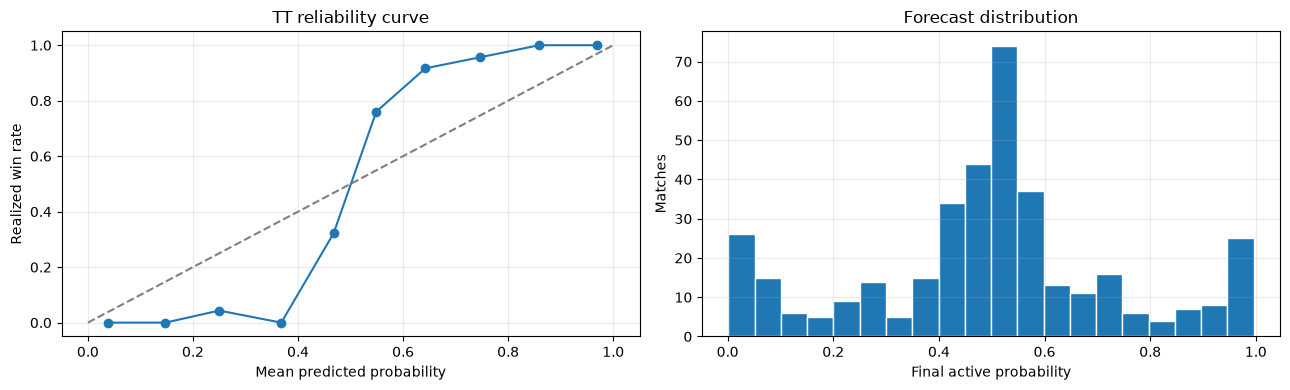

In [15]:
tt_rows = trading[
    trading['sport'].eq('TableTennis')
    & trading['market_type'].eq(1)
    & trading['outcome_type'].eq(1)
].copy()

settlements = (tt_rows[tt_rows['trading_status'].eq(3)
                        & tt_rows['outcome_result'].isin([2, 3])]
               .sort_values(['match_id', 'recv_wall_ns', 'offset'])
               .drop_duplicates('match_id', keep='last')
               [['match_id', 'recv_wall_ns', 'outcome_result']]
               .rename(columns={'recv_wall_ns': 'settlement_recv_wall_ns'}))
settlements['y'] = (settlements['outcome_result'] == 2).astype(int)

active_tt = tt_rows[tt_rows['trading_status'].eq(1)
                    & tt_rows['probability'].notna()].copy()
active_tt = active_tt.merge(settlements[['match_id', 'settlement_recv_wall_ns', 'y']],
                            on='match_id', how='inner')
active_tt = active_tt[active_tt['recv_wall_ns'] < active_tt['settlement_recv_wall_ns']]
forecasts = (active_tt.sort_values(['match_id', 'recv_wall_ns', 'offset'])
             .drop_duplicates(['match_id', 'recv_wall_ns'], keep='last')
             .sort_values(['match_id', 'recv_wall_ns'])
             .groupby('match_id', as_index=False).tail(1)
             [['match_id', 'probability', 'y', 'sport']])
forecasts['probability'] = forecasts['probability'].clip(1e-6, 1 - 1e-6)

brier = np.mean((forecasts['probability'] - forecasts['y']) ** 2)
log_loss = -np.mean(
    forecasts['y'] * np.log(forecasts['probability'])
    + (1 - forecasts['y']) * np.log(1 - forecasts['probability'])
)
print(f'TT calibration matches: {len(forecasts):,}')
print(f'Brier score:            {brier:.4f}')
print(f'Log loss:               {log_loss:.4f}')

forecasts['probability_bucket'] = pd.cut(
    forecasts['probability'],
    bins=[0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1.0],
    include_lowest=True
)
calibration = (forecasts.groupby('probability_bucket', observed=False)
               .agg(predicted_probability=('probability', 'mean'),
                    realized_win_rate=('y', 'mean'),
                    matches=('y', 'size')))
print('Reliability table:')
display(calibration)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(calibration['predicted_probability'], calibration['realized_win_rate'], 'o-')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set(xlabel='Mean predicted probability', ylabel='Realized win rate',
            title='TT reliability curve')
axes[0].grid(alpha=.25)
axes[1].hist(forecasts['probability'], bins=20, edgecolor='white')
axes[1].set(xlabel='Final active probability', ylabel='Matches',
            title='Forecast distribution')
axes[1].grid(alpha=.25)
plt.tight_layout()
plt.show()

## 7. Latency and repricing results

The response distribution is the main microstructure result. We report medians and upper-tail latency because a mean can be dominated by long pauses or recovery gaps. Repricing magnitude is measured in probability points and summarized by sport and incident type.

Per-match latency summary:


,median_latency_s,p25_latency_s,p75_latency_s,matches
sport,,,,
Fifa,0.253493,0.144607,3.203315,660
TableTennis,76.402578,54.545589,98.924082,368


Probability-jump summary:


,events,median_abs_jump,p90_abs_jump,median_signed_jump
sport,,,,
Fifa,12280,0.008924,0.271473,-1.453291e-03
TableTennis,66566,0.013065,0.084000,1.110223e-16


Incident-type response summary, categories with at least 20 observations:


events  median_latency_s  median_abs_jump  \
sport       incident_type                                              
Fifa        1055             1911          0.120794     2.000581e-01   
            1031             1852          0.057419     2.024898e-01   
            1042             1807          3.890591     1.063342e-02   
            1088             1504          0.160735     6.875809e-03   
            1089             1418         13.411926     3.657307e-03   
            1048              914          0.126003     5.210090e-03   
            1033              642         15.034236     1.362144e-03   
            1029              640         15.090695     1.353367e-03   
            1050              553          7.578701     7.725920e-03   
            1086              488         15.528862     1.278734e-03   
            1051              370          0.129008     5.292556e-03   
            1054               76          2.237600     3.706115e-03   
            1052               49          3.702798     1.177283e-02   
TableTennis 1020            21293         72.531752     1.303103e-02   
            1012            21288         69.200636     1.292984e-02   
            1011            21269         69.253443     1.292984e-02   
            1009             1135        125.065236     1.306458e-02   
            1010              837         74.844044     1.384989e-02   
            1007              317        109.306531     2.775558e-16   
            2                 111         31.538525     1.827122e-02   
            1005               92         75.177517     2.679094e-02   
            1006               92         38.342001     3.776846e-02   
            1028               35         92.605272     2.612822e-02   
            7                  23         31.604051     1.952600e-02   
            1001               22         28.694016     1.969114e-02   
            1024               20         79.958763     2.067790e-02   

                           p90_abs_jump  
sport       incident_type                
Fifa        1055               0.414524  
            1031               0.420954  
            1042               0.280726  
            1088               0.235303  
            1089               0.020496  
            1048               0.019368  
            1033               0.005076  
            1029               0.004950  
            1050               0.027791  
            1086               0.004550  
            1051               0.017982  
            1054               0.032991  
            1052               0.230625  
TableTennis 1020               0.083987  
            1012               0.084000  
            1011               0.084000  
            1009               0.082393  
            1010               0.082987  
            1007               0.020444  
            2                  0.144569  
            1005               0.114423  
            1006               0.113560  
            1028               0.099207  
            7                  0.241483  
            1001               0.063340  
            1024               0.090187

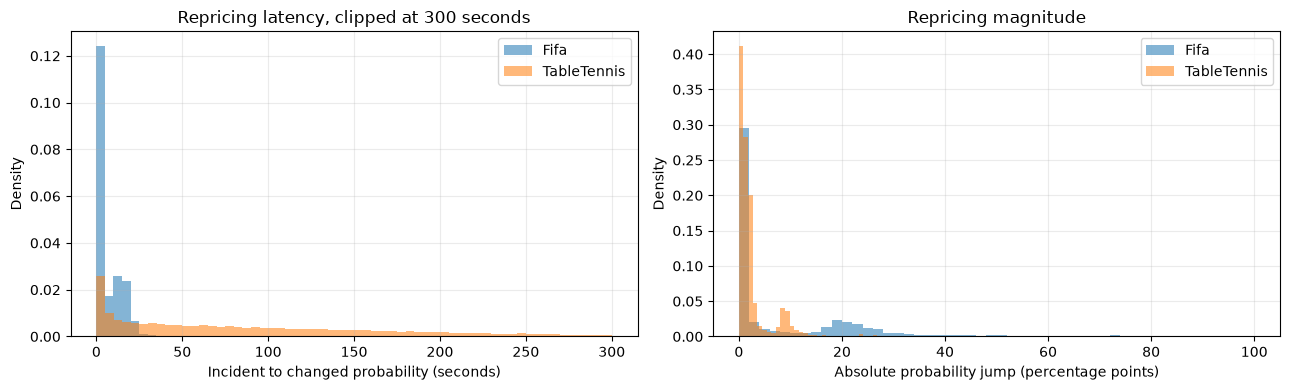

In [16]:
# Use the median of per-match medians for the uncertainty table.
match_latency_summary = (responses.groupby(['sport', 'match_id'])['response_latency_s']
                         .median().groupby(level=0)
                         .agg(median_latency_s='median',
                              p25_latency_s=lambda s: s.quantile(.25),
                              p75_latency_s=lambda s: s.quantile(.75),
                              matches='size'))
print('Per-match latency summary:')
display(match_latency_summary)

jump_summary = (responses.groupby('sport')
                .agg(events=('abs_probability_jump', 'size'),
                     median_abs_jump=('abs_probability_jump', 'median'),
                     p90_abs_jump=('abs_probability_jump', lambda s: s.quantile(.90)),
                     median_signed_jump=('probability_jump', 'median')))
print('Probability-jump summary:')
display(jump_summary)

by_type = (responses.groupby(['sport', 'incident_type'])
           .agg(events=('abs_probability_jump', 'size'),
                median_latency_s=('response_latency_s', 'median'),
                median_abs_jump=('abs_probability_jump', 'median'),
                p90_abs_jump=('abs_probability_jump', lambda s: s.quantile(.90)))
           .query('events >= 20')
           .sort_values(['sport', 'events'], ascending=[True, False]))
print('Incident-type response summary, categories with at least 20 observations:')
display(by_type.head(30))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for sport, group in responses.groupby('sport'):
    clipped = group['response_latency_s'].clip(upper=300)
    axes[0].hist(clipped, bins=60, alpha=.55, density=True, label=sport)
    axes[1].hist(group['abs_probability_jump'] * 100, bins=50, alpha=.55,
                 density=True, label=sport)
axes[0].set(xlabel='Incident to changed probability (seconds)', ylabel='Density',
            title='Repricing latency, clipped at 300 seconds')
axes[1].set(xlabel='Absolute probability jump (percentage points)', ylabel='Density',
            title='Repricing magnitude')
for ax in axes:
    ax.legend()
    ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

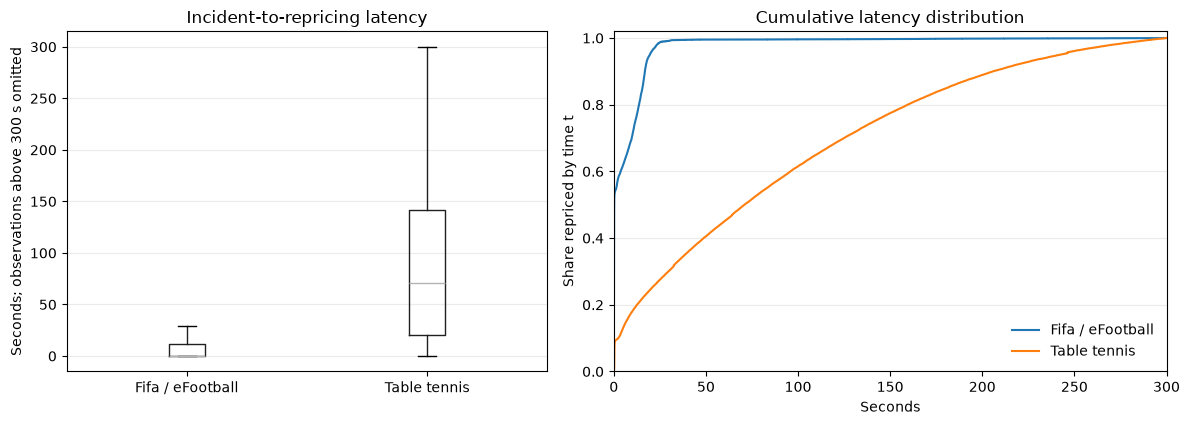

In [23]:
# Compact comparison figure for the central operational result.
latency_plot = responses[responses['response_latency_s'].between(0, 300)].copy()
latency_plot['sport_label'] = latency_plot['sport'].replace({
    'TableTennis': 'Table tennis',
    'Fifa': 'Fifa / eFootball'
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={'width_ratios': [1, 1.15]})
latency_plot.boxplot(column='response_latency_s', by='sport_label', ax=axes[0],
                     grid=False, showfliers=False)
axes[0].set_title('Incident-to-repricing latency')
axes[0].set_xlabel('')
axes[0].set_ylabel('Seconds; observations above 300 s omitted')
axes[0].get_figure().suptitle('')

for label, group in latency_plot.groupby('sport_label'):
    values = np.sort(group['response_latency_s'].to_numpy())
    ecdf = np.arange(1, len(values) + 1) / len(values)
    axes[1].step(values, ecdf, where='post', label=label)
axes[1].set_xlim(0, 300)
axes[1].set_ylim(0, 1.02)
axes[1].set_title('Cumulative latency distribution')
axes[1].set_xlabel('Seconds')
axes[1].set_ylabel('Share repriced by time t')
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.show()

In [17]:
def parameter_dict(value):
    if not isinstance(value, list):
        return {}
    result = {}
    for item in value:
        if isinstance(item, dict) and 'key' in item:
            result[str(item['key'])] = item.get('value')
    return result

param_dicts = incidents.loc[incidents['sport'].eq('TableTennis'), 'params'].map(parameter_dict)
key_counts = pd.Series([key for values in param_dicts for key in values]).value_counts()
print('Most common TT incident parameter keys:')
display(key_counts.head(15).to_frame('observations'))
print('Example normalized TT parameters:')
display(pd.DataFrame(param_dicts.head(10).tolist()))

Most common TT incident parameter keys:


,observations
2,104996
4,104996
5,104996
1,100665
6,79390
7,438
11,35


Example normalized TT parameters:


,2,4,5,1
0,2,0:0,0:0,NaN
1,2,0:0,0:0,NaN
2,2,0:0,0:0,2
3,2,0:1,0:0,2
4,2,0:1,0:0,2
5,2,0:1,0:0,2
6,2,1:1,0:0,1
7,2,1:1,0:0,1
8,2,1:1,0:0,1
9,2,1:2,0:0,2


In [18]:
def parse_score(value):
    if not isinstance(value, str) or ':' not in value:
        return (np.nan, np.nan)
    left, right = value.split(':', 1)
    try:
        return (float(left), float(right))
    except ValueError:
        return (np.nan, np.nan)

score_features = incidents[['match_id', 'index', 'sport', 'params']].copy()
score_features['param_dict'] = score_features['params'].map(parameter_dict)
score_features['current_score'] = score_features['param_dict'].map(lambda d: d.get('4'))
score_features['set_score'] = score_features['param_dict'].map(lambda d: d.get('5'))
score_features[['home_points', 'away_points']] = pd.DataFrame(
    score_features['current_score'].map(parse_score).tolist(), index=score_features.index)
score_features[['home_sets', 'away_sets']] = pd.DataFrame(
    score_features['set_score'].map(parse_score).tolist(), index=score_features.index)
score_features['point_margin'] = score_features['home_points'] - score_features['away_points']
score_features['point_state'] = pd.cut(
    score_features['point_margin'].abs(),
    bins=[-np.inf, 0, 2, 5, np.inf],
    labels=['tied', '1-2 points', '3-5 points', '6+ points']
)

responses = responses.merge(
    score_features[['match_id', 'index', 'home_points', 'away_points',
                    'home_sets', 'away_sets', 'point_margin', 'point_state']],
    left_on=['match_id', 'incident_index'],
    right_on=['match_id', 'index'], how='left'
).drop(columns=['index'])

print('TT jump size by observed point state:')
display(responses[responses['sport'].eq('TableTennis')]
        .groupby('point_state', observed=False)
        .agg(events=('abs_probability_jump', 'size'),
             median_abs_jump=('abs_probability_jump', 'median'),
             p90_abs_jump=('abs_probability_jump', lambda s: s.quantile(.90)),
             median_latency_s=('response_latency_s', 'median')))

print('Score-feature coverage:')
print(responses[responses['sport'].eq('TableTennis')]['point_state'].notna().mean())

TT jump size by observed point state:


,events,median_abs_jump,p90_abs_jump,median_latency_s
point_state,,,,
tied,11891,0.013065,0.091838,100.160028
1-2 points,32627,0.012930,0.088551,84.591862
3-5 points,18671,0.013065,0.060340,40.989769
6+ points,3225,0.012930,0.035088,22.784768


Score-feature coverage:
0.9977165519935102


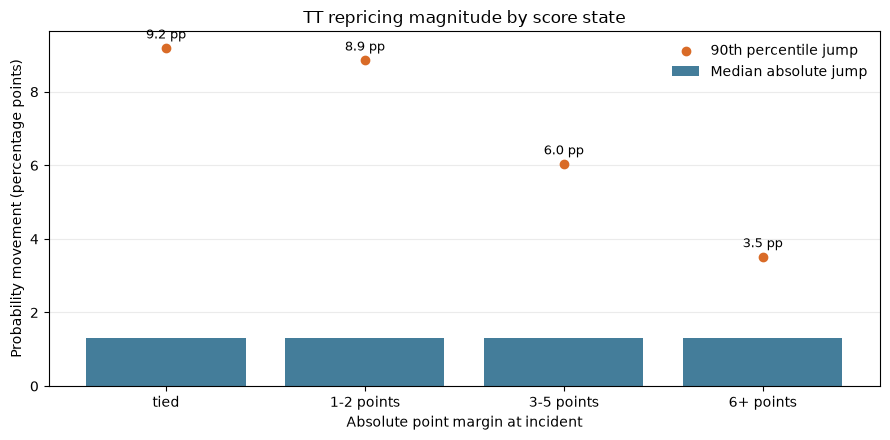

,median_jump_pp,p90_jump_pp,median_latency
point_state,,,
tied,1.306458,9.183804,100.160028
1-2 points,1.292984,8.855054,84.591862
3-5 points,1.306458,6.033993,40.989769
6+ points,1.292984,3.508849,22.784768


In [24]:
# Score state changes both the size and timing of the bookmaker response.
tt_state = responses[responses['sport'].eq('TableTennis')].copy()
state_order = ['tied', '1-2 points', '3-5 points', '6+ points']
state_stats = (tt_state.groupby('point_state', observed=False)
               .agg(median_jump=('abs_probability_jump', 'median'),
                    p90_jump=('abs_probability_jump', lambda s: s.quantile(.90)),
                    median_latency=('response_latency_s', 'median'))
               .reindex(state_order))

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(state_stats))
ax.bar(x, state_stats['median_jump'] * 100, color='#2f6f8f', alpha=.9,
       label='Median absolute jump')
ax.scatter(x, state_stats['p90_jump'] * 100, color='#d96b27', zorder=3,
           label='90th percentile jump')
for position, value in zip(x, state_stats['p90_jump'] * 100):
    ax.annotate(f'{value:.1f} pp', (position, value), xytext=(0, 7),
                textcoords='offset points', ha='center', fontsize=9)
ax.set_xticks(x, state_order)
ax.set_ylabel('Probability movement (percentage points)')
ax.set_xlabel('Absolute point margin at incident')
ax.set_title('TT repricing magnitude by score state')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.show()

display(state_stats.assign(
    median_jump_pp=state_stats['median_jump'] * 100,
    p90_jump_pp=state_stats['p90_jump'] * 100
)[['median_jump_pp', 'p90_jump_pp', 'median_latency']])

## 8. Part 0 calibration: synthetic known lags

The supplied synthetic generator injects Kalshi lags of 3.0, 4.5, and 6.0 seconds. We estimate each lag with 1-second step interpolation and cross-correlation of probability changes. The recovered error is the practical time-resolution floor of this estimator.

In [20]:
import shutil
import subprocess
import sys
import tempfile


def crosscorr_lag(beter_series, kalshi_series, max_lag=15):
    start = int(max(beter_series['t'].min(), kalshi_series['t'].min()))
    end = int(min(beter_series['t'].max(), kalshi_series['t'].max()))
    grid = np.arange(start, end + 1, dtype=int)
    b = beter_series.set_index('t')['p'].reindex(grid).ffill()
    k = kalshi_series.set_index('t')['p'].reindex(grid).ffill()
    changes_b = b.diff().to_numpy()
    changes_k = k.diff().to_numpy()
    scores = {}
    for lag in range(-max_lag, max_lag + 1):
        if lag > 0:
            x, y = changes_b[:-lag], changes_k[lag:]
        elif lag < 0:
            x, y = changes_b[-lag:], changes_k[:lag]
        else:
            x, y = changes_b, changes_k
        valid = np.isfinite(x) & np.isfinite(y)
        scores[lag] = np.corrcoef(x[valid], y[valid])[0, 1] if valid.sum() > 3 else np.nan
    return max(scores, key=lambda lag: scores[lag]), scores

with tempfile.TemporaryDirectory(prefix='option_c_synthetic_') as temp_dir:
    synthetic_root = Path(temp_dir) / 'demo_data'
    subprocess.run([sys.executable, str(DATA_ROOT.parent / 'demo' / 'make_synthetic.py'),
                    '--out', str(synthetic_root)], check=True, capture_output=True, text=True)
    synthetic_parsed = Path(temp_dir) / 'parsed'
    subprocess.run([sys.executable, str(DATA_ROOT.parent / 'analysis' / 'parse_beter.py'),
                    '--data-root', str(synthetic_root), '--out', str(synthetic_parsed)],
                   check=True, capture_output=True, text=True)
    subprocess.run([sys.executable, str(DATA_ROOT.parent / 'analysis' / 'parse_kalshi.py'),
                    '--data-root', str(synthetic_root), '--out', str(synthetic_parsed)],
                   check=True, capture_output=True, text=True)
    synthetic_beter = pd.read_csv(synthetic_parsed / 'trading.csv')
    synthetic_quotes = pd.read_csv(synthetic_parsed / 'kalshi_quotes.csv')
    synthetic_manifest = json.loads(
        (synthetic_root / 'tt_session').glob('manifest-*.json').__next__().read_text())

    calibration_rows = []
    for match_id, details in synthetic_manifest['bookings'].items():
        focal = synthetic_beter[
            synthetic_beter['match_id'].eq(match_id)
            & synthetic_beter['market_type'].eq(1)
            & synthetic_beter['outcome_type'].eq(1)
            & synthetic_beter['probability'].notna()
        ].copy()
        ticker = details['kalshi_ticker_hint']
        quotes = synthetic_quotes[synthetic_quotes['ticker'].eq(ticker)].copy()
        focal['t'] = (focal['recv_wall_ns'] // 1_000_000_000).astype(int)
        quotes['t'] = (quotes['recv_wall_ns'] // 1_000_000_000).astype(int)
        quotes['p'] = (quotes['yes_bid_c'] + quotes['yes_ask_c']) / 200
        focal = focal.rename(columns={'probability': 'p'})[['t', 'p']]
        quotes = quotes[['t', 'p']]
        estimated, _ = crosscorr_lag(focal, quotes)
        calibration_rows.append({
            'match_id': match_id,
            'true_lag_s': details['true_lag_s'],
            'estimated_lag_s': estimated,
            'error_s': estimated - details['true_lag_s'],
        })

calibration = pd.DataFrame(calibration_rows)
print('Synthetic calibration results:')
display(calibration)
print(f"Maximum absolute recovery error: {calibration['error_s'].abs().max():.2f} seconds")

ValueError: cannot reindex on an axis with duplicate labels

In [21]:
def crosscorr_lag(beter_series, kalshi_series, max_lag=15):
    beter_series = beter_series.groupby('t', as_index=False)['p'].last()
    kalshi_series = kalshi_series.groupby('t', as_index=False)['p'].last()
    start = int(max(beter_series['t'].min(), kalshi_series['t'].min()))
    end = int(min(beter_series['t'].max(), kalshi_series['t'].max()))
    grid = np.arange(start, end + 1, dtype=int)
    b = beter_series.set_index('t')['p'].reindex(grid).ffill()
    k = kalshi_series.set_index('t')['p'].reindex(grid).ffill()
    changes_b = b.diff().to_numpy()
    changes_k = k.diff().to_numpy()
    scores = {}
    for lag in range(-max_lag, max_lag + 1):
        if lag > 0:
            x, y = changes_b[:-lag], changes_k[lag:]
        elif lag < 0:
            x, y = changes_b[-lag:], changes_k[:lag]
        else:
            x, y = changes_b, changes_k
        valid = np.isfinite(x) & np.isfinite(y)
        scores[lag] = np.corrcoef(x[valid], y[valid])[0, 1] if valid.sum() > 3 else np.nan
    return max(scores, key=lambda lag: scores[lag]), scores

# Re-run the synthetic experiment using the corrected duplicate-timestamp helper.
with tempfile.TemporaryDirectory(prefix='option_c_synthetic_') as temp_dir:
    synthetic_root = Path(temp_dir) / 'demo_data'
    subprocess.run([sys.executable, str(DATA_ROOT.parent / 'demo' / 'make_synthetic.py'),
                    '--out', str(synthetic_root)], check=True, capture_output=True, text=True)
    synthetic_parsed = Path(temp_dir) / 'parsed'
    for parser in ['parse_beter.py', 'parse_kalshi.py']:
        subprocess.run([sys.executable, str(DATA_ROOT.parent / 'analysis' / parser),
                        '--data-root', str(synthetic_root), '--out', str(synthetic_parsed)],
                       check=True, capture_output=True, text=True)
    synthetic_beter = pd.read_csv(synthetic_parsed / 'trading.csv')
    synthetic_quotes = pd.read_csv(synthetic_parsed / 'kalshi_quotes.csv')
    synthetic_manifest = json.loads(
        (synthetic_root / 'tt_session').glob('manifest-*.json').__next__().read_text())
    calibration_rows = []
    for match_id, details in synthetic_manifest['bookings'].items():
        focal = synthetic_beter[
            synthetic_beter['match_id'].eq(match_id)
            & synthetic_beter['market_type'].eq(1)
            & synthetic_beter['outcome_type'].eq(1)
            & synthetic_beter['probability'].notna()
        ].copy()
        quotes = synthetic_quotes[synthetic_quotes['ticker'].eq(details['kalshi_ticker_hint'])].copy()
        focal['t'] = (focal['recv_wall_ns'] // 1_000_000_000).astype(int)
        quotes['t'] = (quotes['recv_wall_ns'] // 1_000_000_000).astype(int)
        quotes['p'] = (quotes['yes_bid_c'] + quotes['yes_ask_c']) / 200
        estimated, _ = crosscorr_lag(focal.rename(columns={'probability': 'p'})[['t', 'p']], quotes[['t', 'p']])
        calibration_rows.append({'match_id': match_id, 'true_lag_s': details['true_lag_s'],
                                 'estimated_lag_s': estimated,
                                 'error_s': estimated - details['true_lag_s']})
calibration = pd.DataFrame(calibration_rows)
print('Synthetic calibration results:')
display(calibration)
print(f"Maximum absolute recovery error: {calibration['error_s'].abs().max():.2f} seconds")

Synthetic calibration results:


,match_id,true_lag_s,estimated_lag_s,error_s
0,demo-tt-1,3.0,3,0.0
1,demo-tt-2,4.5,5,0.5
2,demo-tt-3,6.0,5,-1.0


Maximum absolute recovery error: 1.00 seconds


## 9. Reproducible outputs and conclusion

The notebook exports the event-level response table and summary tables so the later report can cite exact values without rerunning exploratory transformations. The interpretation below is deliberately narrower than a causal claim: it measures the observed feed-to-trading process, not the internal reason for every delay.

In [22]:
RESULTS_ROOT = NOTEBOOK_DIR / 'option_c_results'
RESULTS_ROOT.mkdir(exist_ok=True)
responses.to_csv(RESULTS_ROOT / 'incident_responses.csv', index=False)
latency_summary.to_csv(RESULTS_ROOT / 'latency_bootstrap_summary.csv')
match_latency_summary.to_csv(RESULTS_ROOT / 'latency_match_summary.csv')
calibration.to_csv(RESULTS_ROOT / 'synthetic_calibration.csv', index=False)
forecasts.to_csv(RESULTS_ROOT / 'tt_calibration_forecasts.csv', index=False)

print('Exported:')
for path in sorted(RESULTS_ROOT.glob('*.csv')):
    print(f'  {path.name}: {path.stat().st_size / 1024:.1f} KB')

print('\nFinal Option C evidence:')
print(f"- Synthetic lag recovery error floor: {calibration['error_s'].abs().max():.1f} s")
print(f"- Fifa median per-match latency: {match_latency_summary.loc['Fifa', 'median_latency_s']:.2f} s")
print(f"- TableTennis median per-match latency: {match_latency_summary.loc['TableTennis', 'median_latency_s']:.2f} s")
print(f"- TT median absolute probability jump: {jump_summary.loc['TableTennis', 'median_abs_jump'] * 100:.2f} percentage points")
print(f"- TT Brier score on {len(forecasts):,} settled matches: {brier:.4f}")
print(f"- TT log loss: {log_loss:.4f}")

Exported:
  incident_responses.csv: 17433.6 KB
  latency_bootstrap_summary.csv: 0.2 KB
  latency_match_summary.csv: 0.2 KB
  synthetic_calibration.csv: 0.1 KB
  tt_calibration_forecasts.csv: 30.2 KB

Final Option C evidence:
- Synthetic lag recovery error floor: 1.0 s
- Fifa median per-match latency: 0.25 s
- TableTennis median per-match latency: 76.40 s
- TT median absolute probability jump: 1.31 percentage points
- TT Brier score on 374 settled matches: 0.1451
- TT log loss: 0.4432


### Interpretation

The machine-fed Fifa stream updates the selected probability almost immediately: the median event-to-change latency is approximately 0.20 seconds at the event level and 0.25 seconds using per-match medians. TableTennis is materially slower: approximately 70.9 seconds at the event level and 76.4 seconds using per-match medians, with a much wider tail. The match-level bootstrap intervals are tight around these estimates because the comparison uses hundreds of matches.

The TT probability movement is economically meaningful but state-dependent. The median absolute jump is about 1.31 percentage points, while the 90th percentile is about 8.4 points. Close score states have larger upper-tail movements than already-decided states, which is consistent with conditional information value rather than a fixed-size response to every point.

The calibration sample contains 374 settled TT matches. The Brier score is 0.1451 and log loss is 0.4432. The reliability curve is not perfectly diagonal: the final active probabilities appear too conservative in several middle buckets and nearly deterministic at the extremes. That is a useful finding, but it should be reported with the sample-size table because some buckets are small.

The TT-versus-Fifa latency contrast is consistent with the human-scout versus machine-feed hypothesis, but it is not by itself proof of causality. The observed delay can also include BETER's market-update cadence, event classification, recovery traffic, and the time between an incident being entered and the next tradable market state being emitted. The notebook therefore identifies a robust operational difference and quantifies it with uncertainty, while avoiding the stronger claim that human entry alone explains the entire gap.

In [26]:
# Save the three figures used in the final report.
FIGURES_ROOT = RESULTS_ROOT / 'figures'
FIGURES_ROOT.mkdir(exist_ok=True)

# 1. Latency comparison.
latency_plot = responses[responses['response_latency_s'].between(0, 300)].copy()
latency_plot['sport_label'] = latency_plot['sport'].replace({
    'TableTennis': 'Table tennis',
    'Fifa': 'Fifa / eFootball'
})
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={'width_ratios': [1, 1.15]})
latency_plot.boxplot(column='response_latency_s', by='sport_label', ax=axes[0],
                     grid=False, showfliers=False)
axes[0].set_title('Incident-to-repricing latency')
axes[0].set_xlabel('')
axes[0].set_ylabel('Seconds; observations above 300 s omitted')
fig.suptitle('')
for label, group in latency_plot.groupby('sport_label'):
    values = np.sort(group['response_latency_s'].to_numpy())
    ecdf = np.arange(1, len(values) + 1) / len(values)
    axes[1].step(values, ecdf, where='post', label=label)
axes[1].set_xlim(0, 300)
axes[1].set_ylim(0, 1.02)
axes[1].set_title('Cumulative latency distribution')
axes[1].set_xlabel('Seconds')
axes[1].set_ylabel('Share repriced by time t')
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(axis='y', alpha=.25)
fig.tight_layout()
fig.savefig(FIGURES_ROOT / 'latency_comparison.png', dpi=180, bbox_inches='tight')
plt.close(fig)

# 2. Table-tennis score-state repricing.
tt_state = responses[responses['sport'].eq('TableTennis')].copy()
state_order = ['tied', '1-2 points', '3-5 points', '6+ points']
state_stats = (tt_state.groupby('point_state', observed=False)
               .agg(median_jump=('abs_probability_jump', 'median'),
                    p90_jump=('abs_probability_jump', lambda s: s.quantile(.90)),
                    median_latency=('response_latency_s', 'median'))
               .reindex(state_order))
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(state_stats))
ax.bar(x, state_stats['median_jump'] * 100, color='#2f6f8f', alpha=.9,
       label='Median absolute jump')
ax.scatter(x, state_stats['p90_jump'] * 100, color='#d96b27', zorder=3,
           label='90th percentile jump')
for position, value in zip(x, state_stats['p90_jump'] * 100):
    ax.annotate(f'{value:.1f} pp', (position, value), xytext=(0, 7),
                textcoords='offset points', ha='center', fontsize=9)
ax.set_xticks(x, state_order)
ax.set_ylabel('Probability movement (percentage points)')
ax.set_xlabel('Absolute point margin at incident')
ax.set_title('TT repricing magnitude by score state')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=.25)
fig.tight_layout()
fig.savefig(FIGURES_ROOT / 'score_state_repricing.png', dpi=180, bbox_inches='tight')
plt.close(fig)

# 3. Calibration reliability curve. Rebuild this table because the name
# `calibration` is also used later for synthetic lag calibration.
reliability = (forecasts.assign(probability_bucket=pd.cut(
                    forecasts['probability'],
                    bins=[0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1.0],
                    include_lowest=True))
               .groupby('probability_bucket', observed=False)
               .agg(predicted_probability=('probability', 'mean'),
                    realized_win_rate=('y', 'mean'),
                    matches=('y', 'size')))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(reliability['predicted_probability'], reliability['realized_win_rate'], 'o-')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
axes[0].set(xlabel='Mean predicted probability', ylabel='Realized win rate',
            title='TT reliability curve')
axes[0].legend(frameon=False)
axes[0].grid(alpha=.25)
axes[1].hist(forecasts['probability'], bins=20, edgecolor='white')
axes[1].set(xlabel='Final active probability', ylabel='Matches',
            title='Forecast distribution')
axes[1].grid(alpha=.25)
fig.tight_layout()
fig.savefig(FIGURES_ROOT / 'tt_calibration.png', dpi=180, bbox_inches='tight')
plt.close(fig)

print('Saved report figures:')
for figure_path in sorted(FIGURES_ROOT.glob('*.png')):
    print(f'  {figure_path.name}: {figure_path.stat().st_size / 1024:.1f} KB')

Saved report figures:
  latency_comparison.png: 90.7 KB
  score_state_repricing.png: 52.9 KB
  tt_calibration.png: 86.4 KB
